In [154]:
import pandas as pd
from src.indices.ipp_calculator import IPPCalculator
from src.indices.equality_index_calculator import EqualityIndexCalculator


# Load your data
df_parls_raw = pd.read_csv("./data/df_parl_detalhes.csv", index_col=0, dtype={'cpf': str})

legislaturas = df_parls_raw["ultimoStatus.idLegislatura"].unique()

# Load Parl data

In [145]:
df_tse_candidatos = pd.read_csv("./data/df_tse_candidatos.csv")
df_tse_candidatos["cpf"] = df_tse_candidatos["cpf"].astype(str).str.zfill(11)

## Load race data

In [158]:
df_parls_raw["cpf"] = df_parls_raw["cpf"].astype(str).str.zfill(11)

df_tse_candidatos = df_tse_candidatos[['cpf', 'raca']].dropna()

df_parls_raw_with_race= df_parls_raw.merge(df_tse_candidatos, on="cpf", how="left")

## Add race data

In [186]:
# Equality data
df_parls = df_parls_raw.copy()

df_parls = df_parls.join(pd.get_dummies(df_parls["sexo"]))
df_parls = df_parls.join(pd.get_dummies(df_parls["escolaridade"]))
df_parls = df_parls.join(pd.get_dummies(df_parls_raw_with_race["raca"]))

df_parls.set_index(["id", "ultimoStatus.idLegislatura"], inplace=True)


## Define your population proportions
population_proportions = {
    "F": 0.52,
    "M": 0.48,
    "branca": 0.2,
    "parda": 0.4,
    "preta": 0.1,
    "amarela": 0.05,
    "indigena": 0.05,
}
df_for_equality = df_parls[population_proportions.keys()].astype(int).copy()


## Load IPP data

In [187]:
# IPP data
df = pd.read_excel("./outputs/df_res.xlsx")
df["mesa_cum"] = df["mesa_1_cum"] + df["mesa_2_cum"]

df["mandatos_cum"] = (
    df["mand_dep_estadual_cum"] + df["mand_sen_cum"] + df["mand_dep_estadual_cum"]
)

df.set_index(["id", "idLegislatura"], inplace=True)


# Calculate indexes

In [188]:
# Calculate IPP
ipp_calculator = IPPCalculator()
df_with_ipp = pd.DataFrame()
for legislatura in legislaturas:
    df_legislatura = df.loc[pd.IndexSlice[:, legislatura], :]
    df_calc = ipp_calculator.calculate(df_legislatura)
    df_with_ipp = pd.concat([df_with_ipp, df_calc])


In [189]:
aggeregated_index = []
df_with_equality = pd.DataFrame()
for legislatura in legislaturas:
    df_legislatura = df_for_equality.loc[pd.IndexSlice[:, legislatura], :]

    # Calculate equality index
    calculator = EqualityIndexCalculator()
    df_calc = calculator.calculate(df_legislatura, population_proportions)

    df_with_equality = pd.concat([df_with_equality, df_calc])

    aggeregated_index.append(
        {"legislatura": legislatura, "index": calculator.adjustment_index}
    )

# # Save results
# df_with_equality.to_csv('./outputs/df_equality_index.csv')

# Print adjustment index
print(f"Overall Equality Index: {calculator.adjustment_index:.4f}")

# Analyze weights distribution
print("\nWeight Distribution Summary:")
print(df_with_equality["equality_weight"].describe())

Overall Equality Index: 0.1660

Weight Distribution Summary:
count    3123.000000
mean        1.000000
std         1.206716
min         0.274178
25%         0.334806
50%         0.546381
75%         1.622374
max        17.563378
Name: equality_weight, dtype: float64


<Axes: xlabel='legislatura'>

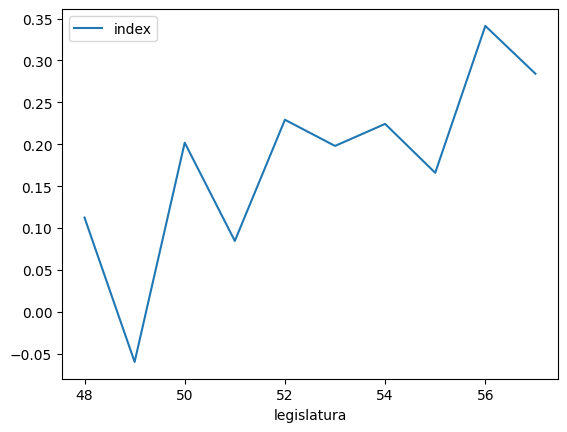

In [ ]:
pd.DataFrame(sorted(aggeregated_index, key=lambda x: x["legislatura"])).plot(
    x="legislatura", y="index", kind="line"
)

In [182]:
df_joined = df_with_ipp.join(df_with_equality)

<Axes: xlabel='equality_weight', ylabel='ipp'>

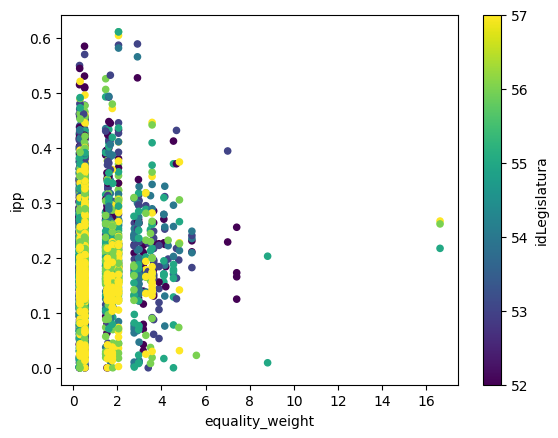

In [183]:
# df_joined.loc[pd.IndexSlice[:, 57], :].reset_index().plot.scatter(
#     x="equality_weight", y="ipp", c="idLegislatura", cmap="viridis"
# )
df_joined.reset_index().plot.scatter(
    x="equality_weight", y="ipp", c="idLegislatura", cmap="viridis"
)